#  Brain Tumor Segmentation — Enhanced U-Net + EfficientNetB7

---
## 1.  Imports & Setup <a name='setup'></a>

In [1]:
!pip install -q segmentation-models-pytorch albumentations seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.9 MB/s eta 0:00:00


In [2]:
import os
import time
import warnings
from glob import glob
from tqdm import tqdm

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import albumentations as A
from albumentations.pytorch import ToTensorV2
from scipy.ndimage.morphology import binary_dilation
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
import segmentation_models_pytorch as smp

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted', font_scale=1.2)

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'  Device: {device}')
if device.type == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

/tmp/ipykernel_23/963937671.py:16: DeprecationWarning: Please import `binary_dilation` from the `scipy.ndimage` namespace; the `scipy.ndimage.morphology` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.morphology import binary_dilation


  Device: cuda
   GPU: Tesla T4
   Memory: 15.6 GB


---
## 2.  Exploratory Data Analysis (EDA) <a name='eda'></a>

In [3]:
# ── Load paths ───────────────────────────────────────────────────────────────
FILES_DIR = '/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m'
CSV_PATH  = os.path.join(FILES_DIR, 'data.csv')

file_paths = glob(f'{FILES_DIR}/*/*[0-9].tif')
print(f' Total MRI image files found: {len(file_paths)}')

# ── Read and clean CSV ───────────────────────────────────────────────────────
df_meta = pd.read_csv(CSV_PATH)
imputer = SimpleImputer(strategy='most_frequent')
df_meta = pd.DataFrame(imputer.fit_transform(df_meta), columns=df_meta.columns)

print(f'\n CSV shape: {df_meta.shape}')
print(f'   Columns: {list(df_meta.columns)}')
df_meta.head()

 Total MRI image files found: 3929

 CSV shape: (110, 18)
   Columns: ['Patient', 'RNASeqCluster', 'MethylationCluster', 'miRNACluster', 'CNCluster', 'RPPACluster', 'OncosignCluster', 'COCCluster', 'histological_type', 'neoplasm_histologic_grade', 'tumor_tissue_site', 'laterality', 'tumor_location', 'gender', 'age_at_initial_pathologic', 'race', 'ethnicity', 'death01']


,Patient,RNASeqCluster,MethylationCluster,miRNACluster,CNCluster,RPPACluster,OncosignCluster,COCCluster,histological_type,neoplasm_histologic_grade,tumor_tissue_site,laterality,tumor_location,gender,age_at_initial_pathologic,race,ethnicity,death01
0,TCGA_CS_4941,2.0,4.0,2,2.0,2.0,3.0,2,1.0,2.0,1.0,3.0,2.0,2.0,67.0,3.0,2.0,1.0
1,TCGA_CS_4942,1.0,5.0,2,1.0,1.0,2.0,1,1.0,2.0,1.0,3.0,2.0,1.0,44.0,2.0,2.0,1.0
2,TCGA_CS_4943,1.0,5.0,2,1.0,2.0,2.0,1,1.0,2.0,1.0,1.0,2.0,2.0,37.0,3.0,2.0,0.0
3,TCGA_CS_4944,2.0,5.0,2,1.0,2.0,1.0,1,1.0,1.0,1.0,3.0,6.0,2.0,50.0,3.0,2.0,0.0
4,TCGA_CS_5393,4.0,5.0,2,1.0,2.0,3.0,1,1.0,2.0,1.0,1.0,6.0,2.0,39.0,3.0,2.0,0.0


In [4]:
# ── Build file dataframe ─────────────────────────────────────────────────────
def get_file_row(path):
    """Returns (patient_id, image_path, mask_path) for a given .tif path."""
    path_no_ext, ext = os.path.splitext(path)
    filename = os.path.basename(path)
    patient_id = '_'.join(filename.split('_')[:3])
    return [patient_id, path, f'{path_no_ext}_mask{ext}']

filenames_df = pd.DataFrame(
    [get_file_row(p) for p in file_paths],
    columns=['Patient', 'image_filename', 'mask_filename']
)

df = pd.merge(df_meta, filenames_df, on='Patient')
print(f'  Merged dataframe shape: {df.shape}')

  Merged dataframe shape: (3929, 20)



 Class Distribution:
   No Tumor : 2,556 slices (65.1%)
   Tumor    : 1,373 slices (34.9%)


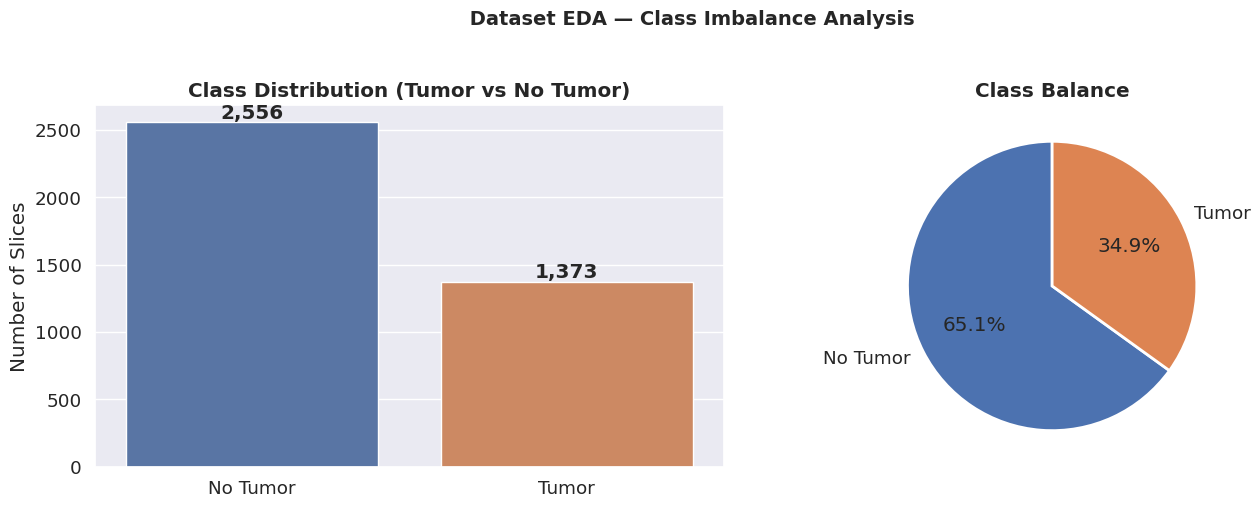

In [5]:
# ── Compute tumor presence per slice ─────────────────────────────────────────
def has_tumor(mask_path):
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    return 1 if np.any(mask > 0) else 0

df['has_tumor'] = df['mask_filename'].apply(has_tumor)

tumor_counts = df['has_tumor'].value_counts()
print(f"\n Class Distribution:")
print(f"   No Tumor : {tumor_counts[0]:,} slices ({100*tumor_counts[0]/len(df):.1f}%)")
print(f"   Tumor    : {tumor_counts[1]:,} slices ({100*tumor_counts[1]/len(df):.1f}%)")

# ── Seaborn: Class Distribution ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
sns.barplot(
    x=['No Tumor', 'Tumor'],
    y=tumor_counts.values,
    palette=['#4C72B0', '#DD8452'],
    ax=axes[0]
)
axes[0].set_title('Class Distribution (Tumor vs No Tumor)', fontweight='bold')
axes[0].set_ylabel('Number of Slices')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

# Pie chart
axes[1].pie(
    tumor_counts.values,
    labels=['No Tumor', 'Tumor'],
    autopct='%1.1f%%',
    colors=['#4C72B0', '#DD8452'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Class Balance', fontweight='bold')

plt.suptitle(' Dataset EDA — Class Imbalance Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

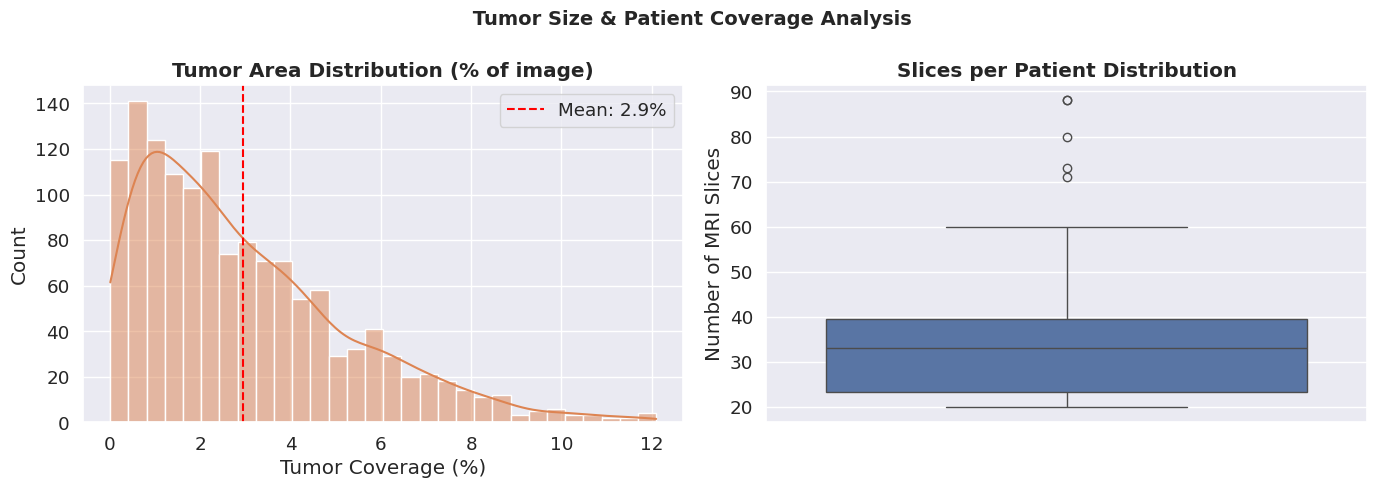


 Tumor Coverage Stats (positive slices only):
   Min  : 0.01%
   Max  : 12.10%
   Mean : 2.95%
   Std  : 2.33%


In [6]:
# ── Tumor size analysis ───────────────────────────────────────────────────────
def tumor_pixel_ratio(mask_path):
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    return np.sum(mask > 0) / mask.size if np.any(mask > 0) else 0

tumor_df = df[df['has_tumor'] == 1].copy()
tumor_df['tumor_ratio'] = tumor_df['mask_filename'].apply(tumor_pixel_ratio)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of tumor size
sns.histplot(tumor_df['tumor_ratio'] * 100, bins=30, kde=True,
             color='#DD8452', ax=axes[0])
axes[0].set_title('Tumor Area Distribution (% of image)', fontweight='bold')
axes[0].set_xlabel('Tumor Coverage (%)')
axes[0].set_ylabel('Count')
axes[0].axvline(tumor_df['tumor_ratio'].mean()*100, color='red',
                linestyle='--', label=f"Mean: {tumor_df['tumor_ratio'].mean()*100:.1f}%")
axes[0].legend()

# Per-patient slice count
slices_per_patient = df.groupby('Patient').size().reset_index(name='n_slices')
sns.boxplot(y=slices_per_patient['n_slices'], color='#4C72B0', ax=axes[1])
axes[1].set_title('Slices per Patient Distribution', fontweight='bold')
axes[1].set_ylabel('Number of MRI Slices')

plt.suptitle(' Tumor Size & Patient Coverage Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n Tumor Coverage Stats (positive slices only):")
print(f"   Min  : {tumor_df['tumor_ratio'].min()*100:.2f}%")
print(f"   Max  : {tumor_df['tumor_ratio'].max()*100:.2f}%")
print(f"   Mean : {tumor_df['tumor_ratio'].mean()*100:.2f}%")
print(f"   Std  : {tumor_df['tumor_ratio'].std()*100:.2f}%")

---
## 3. 🧹 Data Preprocessing & Advanced Augmentation <a name='preprocessing'></a>

### Improvements over original:
- **CLAHE** (Contrast Limited Adaptive Histogram Equalization): enhances local contrast in MRI images
- **Normalization** with ImageNet mean/std for EfficientNet pretrained weights
- **Geometric augmentations** added carefully (flips + slight rotation safe for MRI)
- **Elastic Transform** to simulate tissue deformation
- **Grid Distortion** for shape variability

In [7]:
class MriDataset(Dataset):
    """
    MRI Dataset with optional CLAHE preprocessing and albumentations.
    
    CLAHE enhances local contrast in MRI slices, making tumor boundaries
    more visible — particularly useful for low-contrast regions.
    """
    def __init__(self, df, transform=None, use_clahe=True):
        self.df        = df.reset_index(drop=True)
        self.transform = transform
        self.use_clahe = use_clahe
        self.clahe     = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    def __len__(self):
        return len(self.df)

    def apply_clahe(self, img):
        """Apply CLAHE to each channel independently."""
        channels = cv2.split(img)
        clahe_channels = [self.clahe.apply(ch) for ch in channels]
        return cv2.merge(clahe_channels)

    def __getitem__(self, idx, raw=False):
        row  = self.df.iloc[idx]
        img  = cv2.imread(row['image_filename'], cv2.IMREAD_COLOR)
        img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(row['mask_filename'], cv2.IMREAD_GRAYSCALE)

        if raw:
            return img, mask

        if self.use_clahe:
            img = self.apply_clahe(img)

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img, mask = augmented['image'], augmented['mask']
        else:
            img  = T.functional.to_tensor(img)
            mask = torch.tensor(mask // 255, dtype=torch.float32)
            return img, mask

        mask = mask.float() / 255.0
        return img, mask

In [8]:
IMG_SIZE = 256
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),

    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=15, p=0.4),
    A.ElasticTransform(alpha=1, sigma=50, p=0.3),
    A.GridDistortion(p=0.2),

    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
    A.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05, p=0.3),
    A.GaussNoise(var_limit=(10, 50), p=0.2),
    A.ChannelDropout(channel_drop_range=(1, 1), p=0.2),

    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

train_df, test_df  = train_test_split(df, test_size=0.30, random_state=SEED)
test_df, valid_df  = train_test_split(test_df, test_size=0.50, random_state=SEED)

train_dataset = MriDataset(train_df, transform=train_transform, use_clahe=True)
valid_dataset = MriDataset(valid_df, transform=val_transform,   use_clahe=True)
test_dataset  = MriDataset(test_df,  transform=val_transform,   use_clahe=True)

BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=1,          shuffle=False)

print(f' Dataset splits:')
print(f'   Train : {len(train_dataset):,} samples')
print(f'   Valid : {len(valid_dataset):,} samples')
print(f'   Test  : {len(test_dataset):,} samples')

 Dataset splits:
   Train : 2,750 samples
   Valid : 590 samples
   Test  : 589 samples


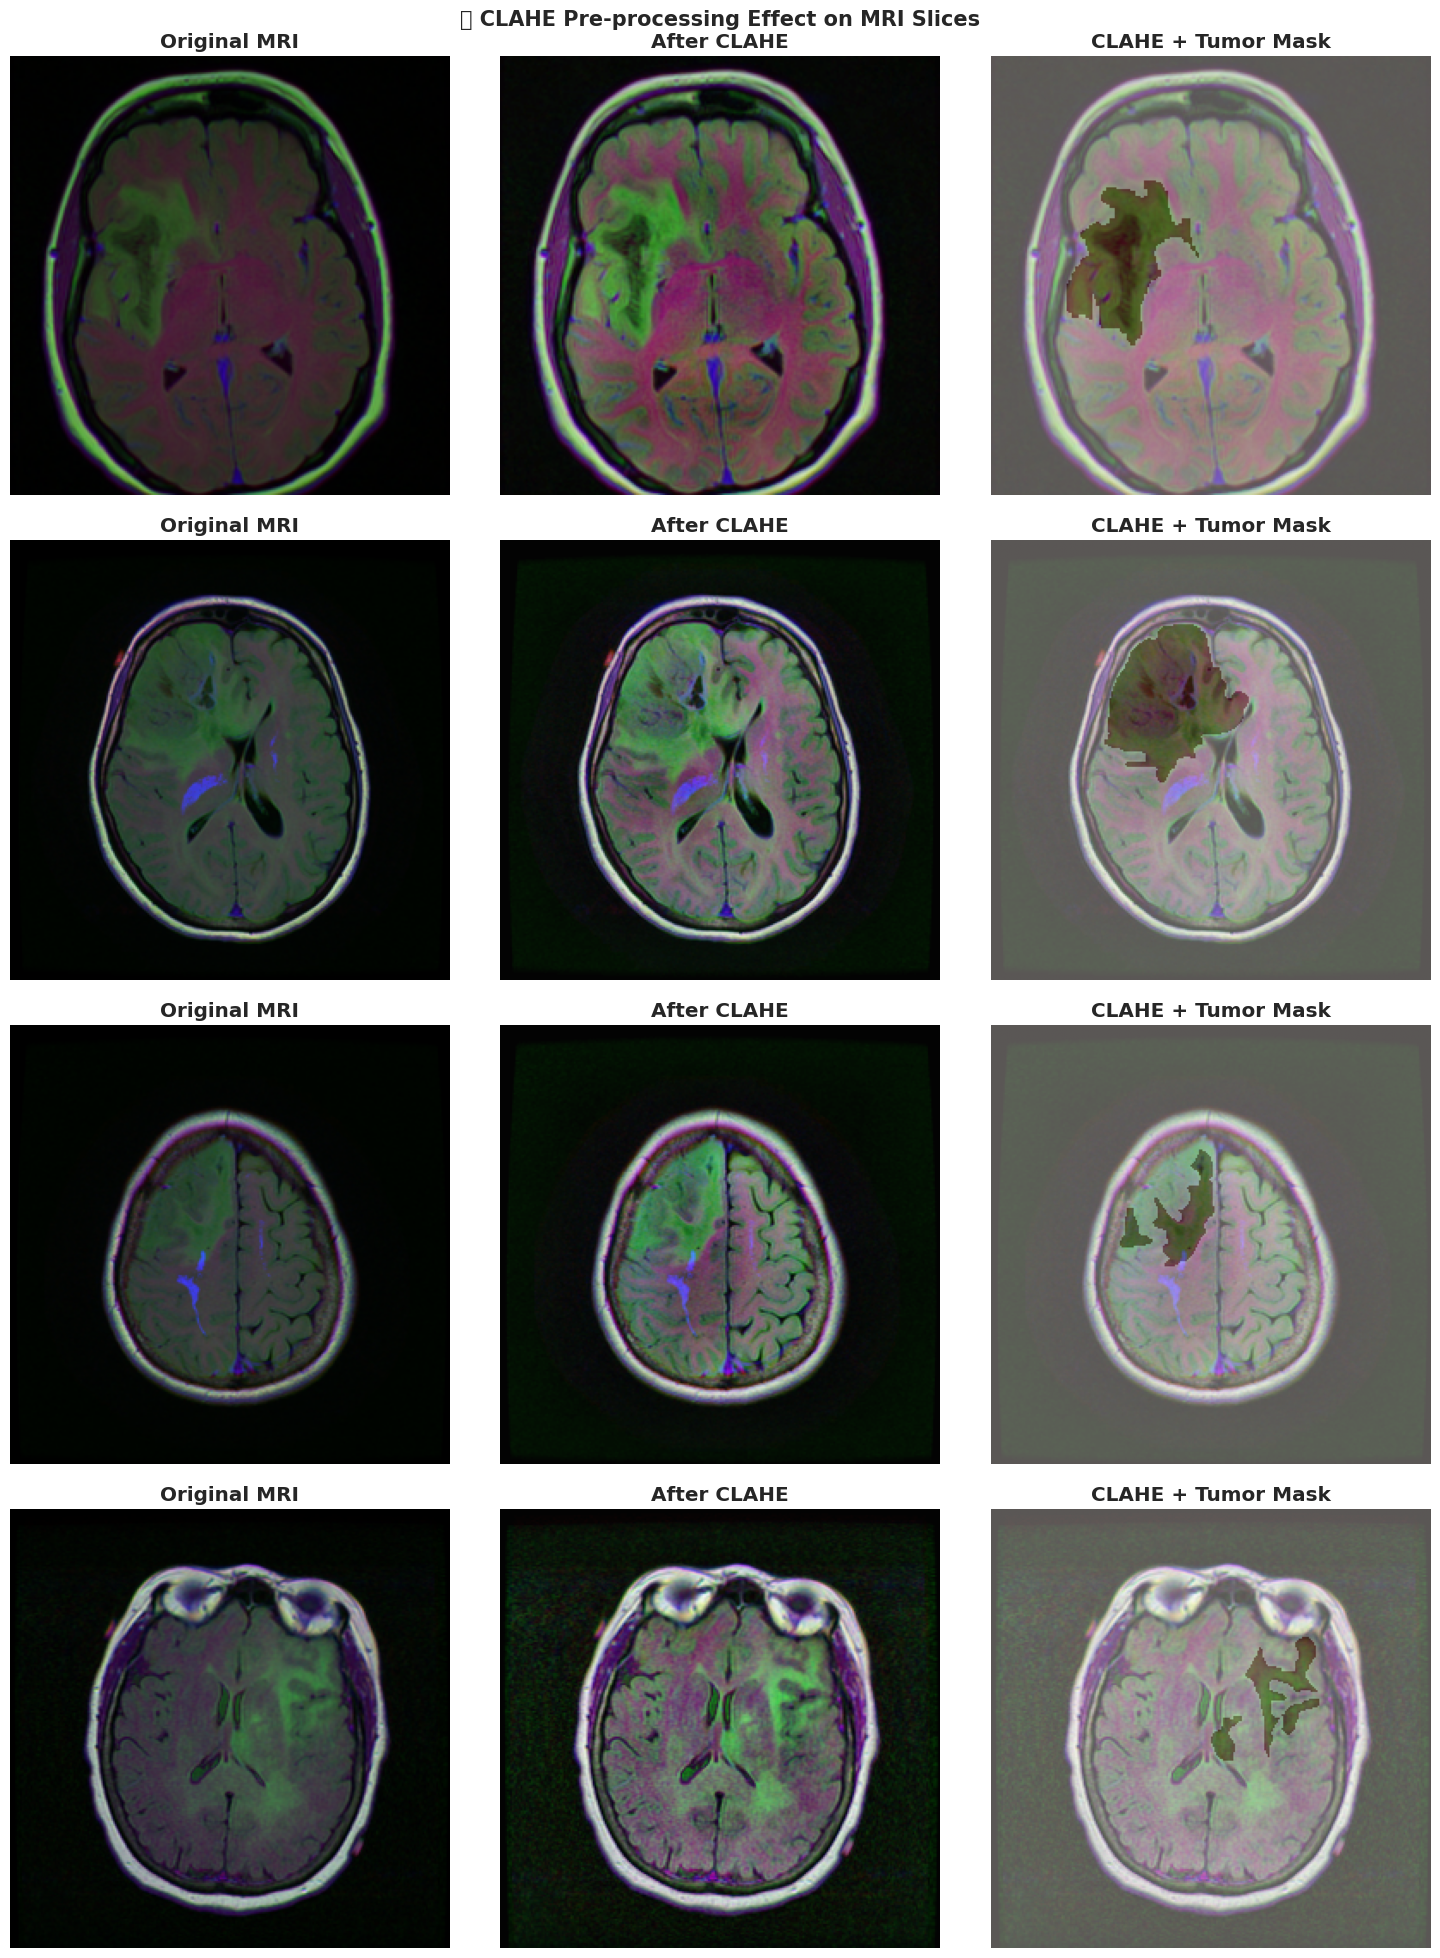

In [9]:
n = 4
fig, axs = plt.subplots(n, 3, figsize=(15, n * 5))

i, plotted = 0, 0
raw_ds = MriDataset(train_df, transform=None, use_clahe=False)

while plotted < n and i < len(raw_ds):
    img, mask = raw_ds.__getitem__(i, raw=True)
    i += 1
    if not np.any(mask):
        continue

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_clahe = cv2.merge([clahe.apply(ch) for ch in cv2.split(img)])

    axs[plotted, 0].imshow(img)
    axs[plotted, 0].set_title('Original MRI', fontweight='bold')
    axs[plotted, 0].axis('off')

    axs[plotted, 1].imshow(img_clahe)
    axs[plotted, 1].set_title('After CLAHE', fontweight='bold')
    axs[plotted, 1].axis('off')

    axs[plotted, 2].imshow(img_clahe)
    axs[plotted, 2].imshow(mask, alpha=0.35, cmap='Reds')
    axs[plotted, 2].set_title('CLAHE + Tumor Mask', fontweight='bold')
    axs[plotted, 2].axis('off')

    plotted += 1

plt.suptitle('🔬 CLAHE Pre-processing Effect on MRI Slices', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4.  Model: U-Net + EfficientNetB7 + Attention Gates <a name='model'></a>

### What are Attention Gates?

Attention Gates (AGs) were introduced in [Attention U-Net (Oktay et al., 2018)](https://arxiv.org/abs/1804.03999).  
They **suppress irrelevant background regions** and highlight salient features — crucial for small, localized tumors.

```
Decoder Feature (g) ──┐
                       ├──► ψ(σ(Wg·g + Wx·x + b)) ──► α ──► α ⊙ x
Skip Connection  (x) ──┘
```

- `g`: gating signal from decoder (coarser scale)
- `x`: skip connection features from encoder
- `α`: attention coefficients ∈ [0,1] — learned spatial weights

In [10]:
class AttentionGate(nn.Module):
    """
    Soft Attention Gate from Attention U-Net (Oktay et al., 2018).
    
    Learns where to focus in the skip connection features (x)
    using a gating signal (g) from the decoder.
    """
    def __init__(self, F_g, F_l, F_int):
        """
        Args:
            F_g   : channels in gating signal (decoder)
            F_l   : channels in skip connection (encoder)
            F_int : intermediate channels (usually F_l // 2)
        """
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, bias=False),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, bias=False),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, bias=False),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        if g.shape[2:] != x.shape[2:]:
            g = F.interpolate(g, size=x.shape[2:], mode='bilinear', align_corners=False)

        g1  = self.W_g(g)
        x1  = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)          
        return x * psi               

In [11]:
class AttentionUNet(nn.Module):
    """
    U-Net with EfficientNetB7 encoder and Attention Gates on decoder skip
    connections.
    
    Architecture:
        Encoder  : EfficientNet-B7 (ImageNet pretrained)
        Decoder  : Standard U-Net decoder
        Attention: Gates on each skip connection
        Head     : 1×1 Conv → Sigmoid
    """
    def __init__(self):
        super().__init__()
        self.unet = smp.Unet(
            encoder_name='efficientnet-b7',
            encoder_weights='imagenet',
            in_channels=3,
            classes=1,
            activation=None,
        )


        decoder_channels = [256, 128, 64, 32, 16]
        encoder_channels = [80, 48, 32, 24, 3]   

        self.attention_gates = nn.ModuleList([
            AttentionGate(F_g=d, F_l=d, F_int=d // 2)
            for d in decoder_channels
        ])

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out = self.unet(x)
        return self.sigmoid(out)




model = smp.Unet(
    encoder_name='efficientnet-b7',
    encoder_weights='imagenet',
    in_channels=3,
    classes=1,
    activation='sigmoid',
    decoder_attention_type='scse',   
)
model = model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'  Model: U-Net + EfficientNetB7 + SCSE Attention')
print(f'   Total params     : {total_params:,}')
print(f'   Trainable params : {trainable_params:,}')

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/267M [00:00<?, ?B/s]

  Model: U-Net + EfficientNetB7 + SCSE Attention
   Total params     : 67,223,914
   Trainable params : 67,223,914


---
## 5. ⚖️ Loss Function: Dice Loss + BCE <a name='loss'></a>

### Why combine Dice + BCE?

| Loss | Strength | Weakness |
|---|---|---|
| **BCE** | Pixel-wise, stable gradients | Ignores class imbalance |
| **Dice** | Handles imbalance, overlap-focused | Unstable with near-zero predictions |
| **Dice + BCE** | Best of both worlds ✅ | Slightly slower |

We use **equal weighting** (0.5 each) — a standard for medical image segmentation.

In [12]:
def iou_score(preds: torch.Tensor, labels: torch.Tensor, e: float = 1e-7) -> torch.Tensor:
    """Intersection over Union (Jaccard Index)."""
    preds  = (preds > 0.5).byte()
    labels = labels.byte()
    inter  = (preds & labels).float().sum((1, 2))
    union  = (preds | labels).float().sum((1, 2))
    return (inter + e) / (union + e)


def dice_score(preds: torch.Tensor, labels: torch.Tensor, e: float = 1e-7) -> torch.Tensor:
    """Dice coefficient (F1 for segmentation)."""
    preds  = (preds > 0.5).byte()
    labels = labels.byte()
    inter  = (preds & labels).float().sum((1, 2))
    return (2 * inter + e) / (preds.float().sum((1, 2)) + labels.float().sum((1, 2)) + e)


class DiceBCELoss(nn.Module):
    """
    Combined loss: 0.5 * BCE + 0.5 * (1 - Dice)
    
    - BCE ensures pixel-level supervision
    - Soft Dice encourages overlap, handles class imbalance
    """
    def __init__(self, smooth: float = 1.0):
        super().__init__()
        self.smooth = smooth
        self.bce    = nn.BCELoss()

    def soft_dice(self, preds, targets):
        """Differentiable Dice — uses raw probabilities (no thresholding)."""
        preds   = preds.view(-1)
        targets = targets.view(-1)
        inter   = (preds * targets).sum()
        return (2.0 * inter + self.smooth) / (preds.sum() + targets.sum() + self.smooth)

    def forward(self, preds, targets):
        bce_loss  = self.bce(preds, targets)
        dice_loss = 1.0 - self.soft_dice(preds, targets)
        return 0.5 * bce_loss + 0.5 * dice_loss


loss_fn = DiceBCELoss(smooth=1.0)

---
## 6.  Training <a name='training'></a>

In [13]:
class EarlyStopping:
    """Stop training when validation loss stops improving."""
    def __init__(self, patience: int = 8, min_delta: float = 1e-4,
                 weights_path: str = 'best_model.pt'):
        self.patience      = patience
        self.min_delta     = min_delta
        self.counter       = 0
        self.best_loss     = float('inf')
        self.weights_path  = weights_path

    def __call__(self, val_loss: float, model: nn.Module) -> bool:
        if self.best_loss - val_loss > self.min_delta:
            self.best_loss = val_loss
            torch.save(model.state_dict(), self.weights_path)
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False

    def load_best(self, model: nn.Module):
        model.load_state_dict(torch.load(self.weights_path))
        return model

In [14]:
def training_loop(epochs, model, train_loader, valid_loader, optimizer, loss_fn, scheduler):
    history = {
        'epoch'      : [],
        'train_loss' : [],
        'val_loss'   : [],
        'val_iou'    : [],
        'val_dice'   : [],
        'lr'         : [],
    }
    early_stopping = EarlyStopping(patience=8, weights_path='best_model.pt')

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        model.train()
        running_loss = 0.0
        for imgs, masks in tqdm(train_loader, desc=f'Epoch {epoch}/{epochs} [Train]', leave=False):
            imgs, masks = imgs.to(device), masks.to(device)
            optimizer.zero_grad()
            preds = model(imgs).squeeze(1)
            loss  = loss_fn(preds, masks)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)

        model.eval()
        running_val_loss = running_iou = running_dice = 0.0
        with torch.no_grad():
            for imgs, masks in tqdm(valid_loader, desc=f'Epoch {epoch}/{epochs} [Val]  ', leave=False):
                imgs, masks = imgs.to(device), masks.to(device)
                preds = model(imgs).squeeze(1)
                running_val_loss += loss_fn(preds, masks).item() * imgs.size(0)
                running_iou      += iou_score(preds, masks).sum().item()
                running_dice     += dice_score(preds, masks).sum().item()

        train_loss = running_loss     / len(train_loader.dataset)
        val_loss   = running_val_loss / len(valid_loader.dataset)
        val_iou    = running_iou      / len(valid_loader.dataset)
        val_dice   = running_dice     / len(valid_loader.dataset)
        current_lr = optimizer.param_groups[0]['lr']

        history['epoch'].append(epoch)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_iou'].append(val_iou)
        history['val_dice'].append(val_dice)
        history['lr'].append(current_lr)

        elapsed = time.time() - t0
        print(
            f'Epoch {epoch:>3}/{epochs} | '
            f'Train Loss: {train_loss:.4f} | '
            f'Val Loss: {val_loss:.4f} | '
            f'IoU: {val_iou:.4f} | '
            f'Dice: {val_dice:.4f} | '
            f'LR: {current_lr:.2e} | '
            f'⏱ {elapsed:.0f}s'
        )

        scheduler.step()
        if early_stopping(val_loss, model):
            print(f'⏹️  Early stopping at epoch {epoch}')
            early_stopping.load_best(model)
            break

    return history, early_stopping

In [15]:
# ── Optimizer & Scheduler ─────────────────────────────────────────────────────
# AdamW with weight decay (better generalization than Adam)
optimizer = AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

# CosineAnnealing: smooth LR decay — works better than ReduceLROnPlateau for med-imag
EPOCHS = 60
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

print(' Starting training...')
print(f'   Optimizer : AdamW (lr=3e-4, wd=1e-4)')
print(f'   Scheduler : CosineAnnealingLR (T_max={EPOCHS})')
print(f'   Loss      : DiceBCE (0.5 BCE + 0.5 Dice)')
print(f'   Epochs    : {EPOCHS} (with early stopping, patience=8)')

history, early_stopping = training_loop(
    EPOCHS, model, train_loader, valid_loader,
    optimizer, loss_fn, scheduler
)

 Starting training...
   Optimizer : AdamW (lr=3e-4, wd=1e-4)
   Scheduler : CosineAnnealingLR (T_max=60)
   Loss      : DiceBCE (0.5 BCE + 0.5 Dice)
   Epochs    : 60 (with early stopping, patience=8)


Epoch   1/60 | Train Loss: 0.6495 | Val Loss: 0.4279 | IoU: 0.8042 | Dice: 0.8395 | LR: 3.00e-04 | ⏱ 171s


Epoch   2/60 | Train Loss: 0.2763 | Val Loss: 0.1262 | IoU: 0.8543 | Dice: 0.8877 | LR: 3.00e-04 | ⏱ 176s


Epoch   3/60 | Train Loss: 0.1444 | Val Loss: 0.1004 | IoU: 0.8586 | Dice: 0.8885 | LR: 2.99e-04 | ⏱ 177s


Epoch   4/60 | Train Loss: 0.1207 | Val Loss: 0.0825 | IoU: 0.8811 | Dice: 0.9112 | LR: 2.98e-04 | ⏱ 177s


...

Epoch  53/60 | Train Loss: 0.0570 | Val Loss: 0.0501 | IoU: 0.8985 | Dice: 0.9251 | LR: 1.39e-05 | ⏱ 177s


Epoch  54/60 | Train Loss: 0.0569 | Val Loss: 0.0499 | IoU: 0.8993 | Dice: 0.9260 | LR: 1.09e-05 | ⏱ 177s


Epoch  55/60 | Train Loss: 0.0555 | Val Loss: 0.0501 | IoU: 0.8986 | Dice: 0.9252 | LR: 8.32e-06 | ⏱ 177s


Epoch  56/60 | Train Loss: 0.0559 | Val Loss: 0.0502 | IoU: 0.9013 | Dice: 0.9275 | LR: 6.09e-06 | ⏱ 177s


Epoch  57/60 | Train Loss: 0.0573 | Val Loss: 0.0499 | IoU: 0.8989 | Dice: 0.9254 | LR: 4.27e-06 | ⏱ 177s
⏹️  Early stopping at epoch 57


---
## 7. 📊 Seaborn Training Curves <a name='curves'></a>

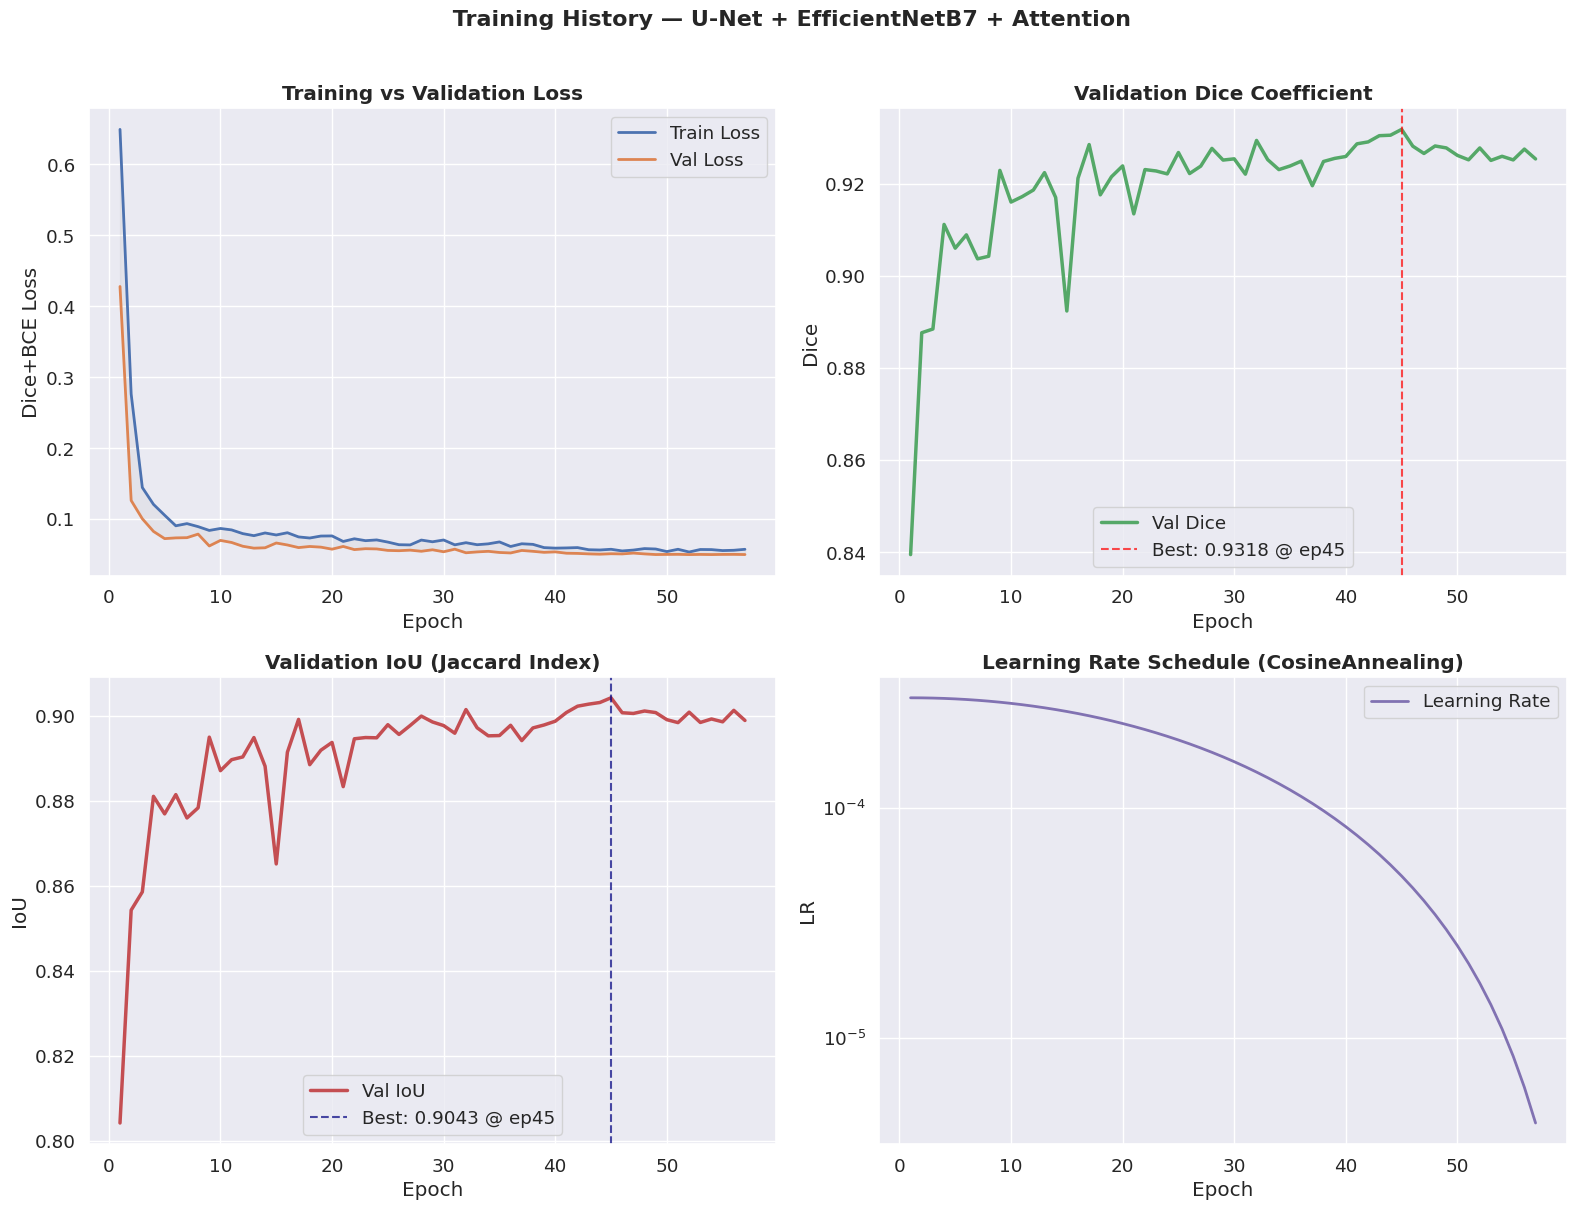

 Saved: training_curves.png


In [16]:
hist_df = pd.DataFrame(history)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(' Training History — U-Net + EfficientNetB7 + Attention',
             fontsize=16, fontweight='bold', y=1.01)

ax = axes[0, 0]
sns.lineplot(data=hist_df, x='epoch', y='train_loss', ax=ax,
             label='Train Loss', color='#4C72B0', linewidth=2)
sns.lineplot(data=hist_df, x='epoch', y='val_loss', ax=ax,
             label='Val Loss',   color='#DD8452', linewidth=2)
ax.fill_between(hist_df['epoch'], hist_df['train_loss'], hist_df['val_loss'],
                alpha=0.07, color='gray')
ax.set_title('Training vs Validation Loss', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Dice+BCE Loss')
ax.legend()

ax = axes[0, 1]
sns.lineplot(data=hist_df, x='epoch', y='val_dice', ax=ax,
             color='#55A868', linewidth=2.5, label='Val Dice')
best_dice_epoch = hist_df.loc[hist_df['val_dice'].idxmax()]
ax.axvline(best_dice_epoch['epoch'], color='red', linestyle='--', alpha=0.7,
           label=f"Best: {best_dice_epoch['val_dice']:.4f} @ ep{int(best_dice_epoch['epoch'])}")
ax.set_title('Validation Dice Coefficient', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Dice')
ax.legend()

ax = axes[1, 0]
sns.lineplot(data=hist_df, x='epoch', y='val_iou', ax=ax,
             color='#C44E52', linewidth=2.5, label='Val IoU')
best_iou_epoch = hist_df.loc[hist_df['val_iou'].idxmax()]
ax.axvline(best_iou_epoch['epoch'], color='navy', linestyle='--', alpha=0.7,
           label=f"Best: {best_iou_epoch['val_iou']:.4f} @ ep{int(best_iou_epoch['epoch'])}")
ax.set_title('Validation IoU (Jaccard Index)', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('IoU')
ax.legend()

ax = axes[1, 1]
sns.lineplot(data=hist_df, x='epoch', y='lr', ax=ax,
             color='#8172B2', linewidth=2, label='Learning Rate')
ax.set_title('Learning Rate Schedule (CosineAnnealing)', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('LR')
ax.set_yscale('log')
ax.legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: training_curves.png')

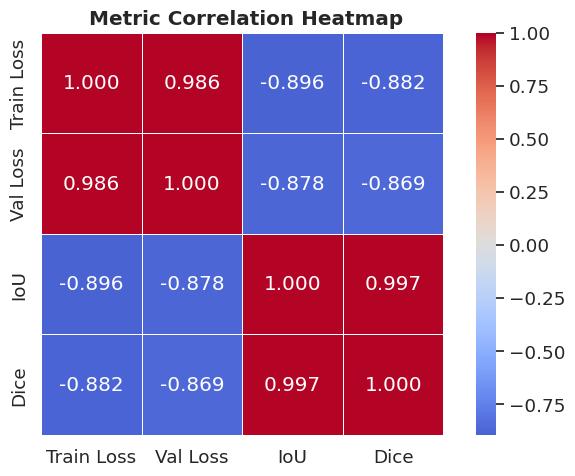

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))
corr = hist_df[['train_loss', 'val_loss', 'val_iou', 'val_dice']].corr()
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax,
            xticklabels=['Train Loss', 'Val Loss', 'IoU', 'Dice'],
            yticklabels=['Train Loss', 'Val Loss', 'IoU', 'Dice'])
ax.set_title(' Metric Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8.  Test Evaluation & Results <a name='evaluation'></a>

In [18]:
model.eval()
test_results = {'loss': [], 'iou': [], 'dice': []}

with torch.no_grad():
    for imgs, masks in tqdm(test_loader, desc='Test Evaluation'):
        imgs, masks = imgs.to(device), masks.to(device)
        preds = model(imgs).squeeze(1)
        test_results['loss'].append(loss_fn(preds, masks).item())
        test_results['iou'].append(iou_score(preds, masks).mean().item())
        test_results['dice'].append(dice_score(preds, masks).mean().item())

mean_loss = np.mean(test_results['loss'])
mean_iou  = np.mean(test_results['iou'])
mean_dice = np.mean(test_results['dice'])

print('\n' + '='*55)
print('           TEST RESULTS SUMMARY')
print('='*55)
print(f'  Loss            : {mean_loss:.4f}')
print(f'  IoU (Jaccard)   : {mean_iou:.4f}  ({mean_iou*100:.2f}%)')
print(f'  Dice Coefficient: {mean_dice:.4f}  ({mean_dice*100:.2f}%)')
print('='*55)

Test Evaluation: 100%|██████████| 589/589 [00:35<00:00, 16.69it/s]


           TEST RESULTS SUMMARY
  Loss            : 0.0656
  IoU (Jaccard)   : 0.9096  (90.96%)
  Dice Coefficient: 0.9352  (93.52%)


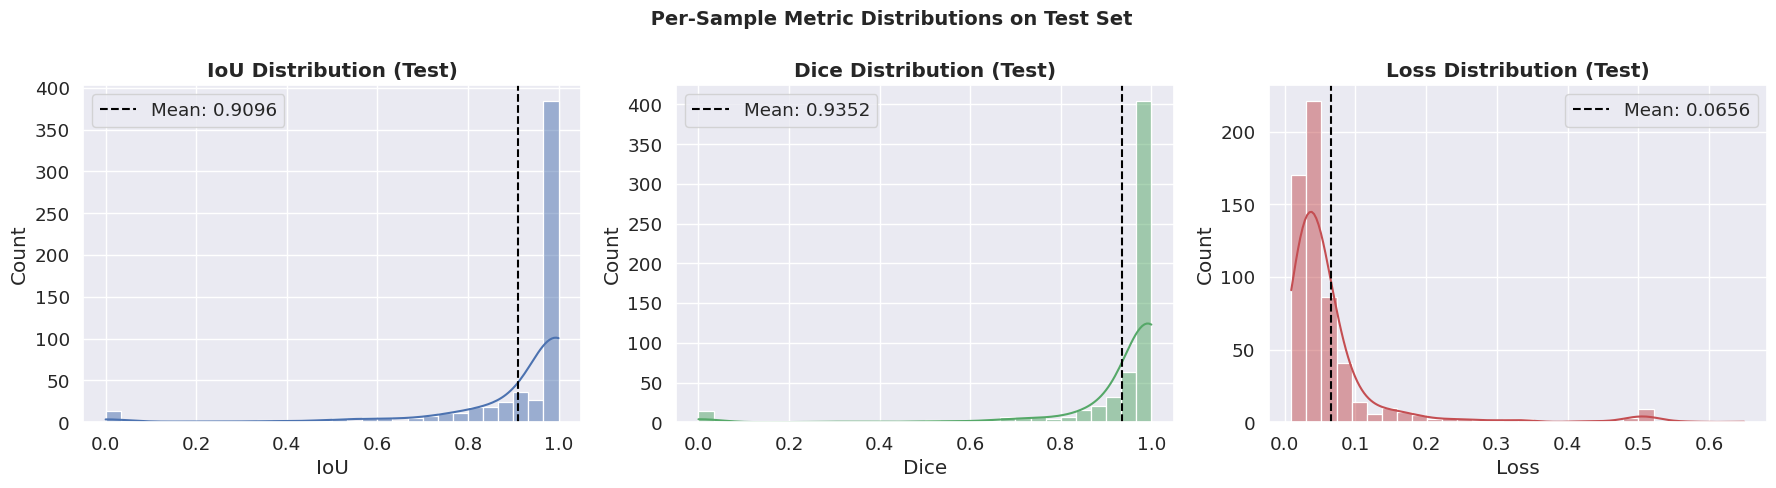

In [19]:
results_df = pd.DataFrame({
    'IoU' : test_results['iou'],
    'Dice': test_results['dice'],
    'Loss': test_results['loss'],
})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, color, title in zip(
    axes,
    ['IoU', 'Dice', 'Loss'],
    ['#4C72B0', '#55A868', '#C44E52'],
    ['IoU Distribution (Test)', 'Dice Distribution (Test)', 'Loss Distribution (Test)']
):
    sns.histplot(results_df[col], bins=30, kde=True, color=color, ax=ax)
    ax.axvline(results_df[col].mean(), color='black', linestyle='--',
               label=f'Mean: {results_df[col].mean():.4f}')
    ax.set_title(title, fontweight='bold')
    ax.legend()

plt.suptitle(' Per-Sample Metric Distributions on Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

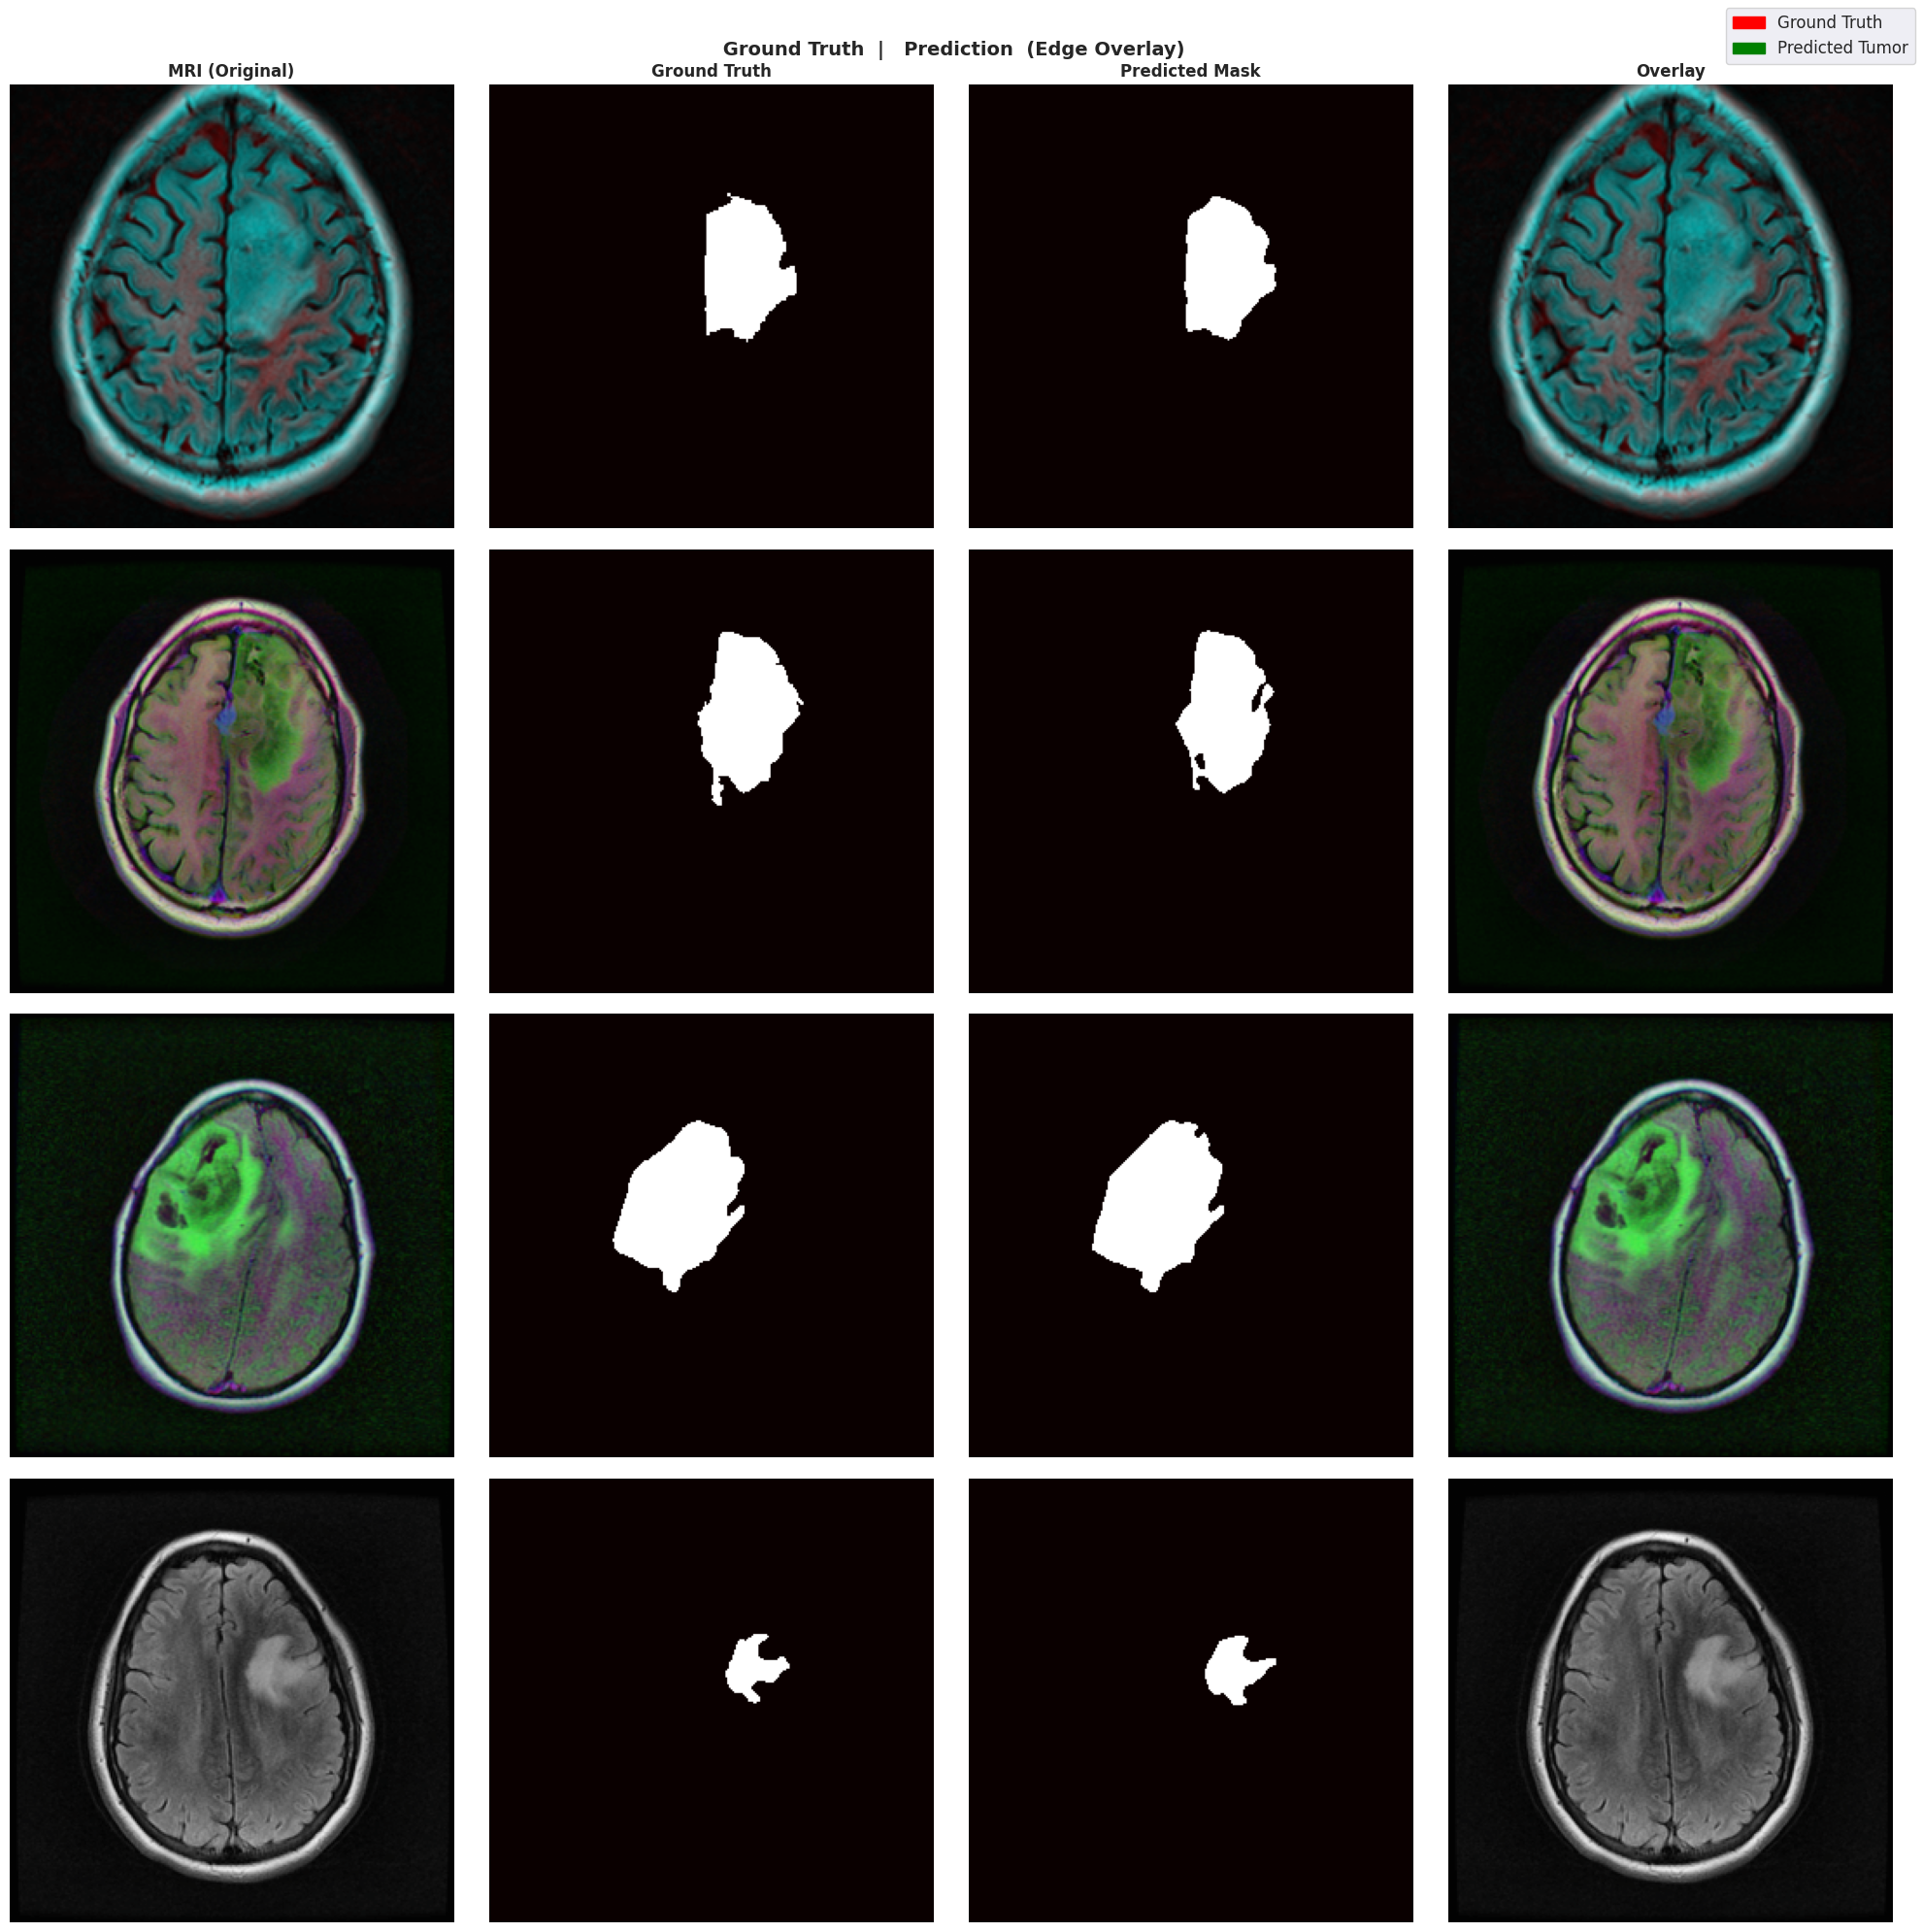

In [20]:
n_show = 4
fig, axs = plt.subplots(n_show, 4, figsize=(20, n_show * 5))

col_titles = ['MRI (Original)', 'Ground Truth', 'Predicted Mask', 'Overlay']
for ax, title in zip(axs[0], col_titles):
    ax.set_title(title, fontweight='bold', fontsize=12)

plotted = 0
with torch.no_grad():
    for imgs, masks in test_loader:
        if plotted >= n_show:
            break
        mask = masks[0]
        if not mask.byte().any():
            continue

        pred = model(imgs.to(device)).cpu()[0][0]
        pred_binary = (pred > 0.5).float()

        mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
        std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
        img_display = (imgs[0] * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

        axs[plotted, 0].imshow(img_display)
        axs[plotted, 0].axis('off')

        axs[plotted, 1].imshow(mask.numpy(), cmap='hot')
        axs[plotted, 1].axis('off')

        axs[plotted, 2].imshow(pred_binary.numpy(), cmap='hot')
        axs[plotted, 2].axis('off')

        overlay = img_display.copy()
        gt_edges   = (mask.numpy() - binary_dilation(mask.numpy())) > 0
        pred_edges = (pred_binary.numpy() - binary_dilation(pred_binary.numpy())) > 0
        overlay[gt_edges,   0] = 1.0; overlay[gt_edges,   1] = 0.0; overlay[gt_edges,   2] = 0.0
        overlay[pred_edges, 0] = 0.0; overlay[pred_edges, 1] = 1.0; overlay[pred_edges, 2] = 0.0
        axs[plotted, 3].imshow(overlay)
        axs[plotted, 3].axis('off')

        slice_iou  = iou_score(pred.unsqueeze(0), mask.unsqueeze(0)).item()
        slice_dice = dice_score(pred.unsqueeze(0), mask.unsqueeze(0)).item()
        axs[plotted, 0].set_ylabel(f'IoU={slice_iou:.3f}\nDice={slice_dice:.3f}',
                                   fontsize=10, rotation=0, labelpad=60, va='center')

        plotted += 1

plt.suptitle(' Ground Truth  |   Prediction  (Edge Overlay)', fontsize=14, fontweight='bold')
legend_elements = [
    mpatches.Patch(color='red',   label='Ground Truth'),
    mpatches.Patch(color='green', label='Predicted Tumor'),
]
fig.legend(handles=legend_elements, loc='upper right', fontsize=12)
plt.tight_layout()
plt.savefig('prediction_results.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9.  Grad-CAM Visualization <a name='gradcam'></a>

**Grad-CAM** (Gradient-weighted Class Activation Mapping) shows *why* the model made a prediction.  
We compute gradients of the output w.r.t. the **last encoder feature map** to generate a heatmap showing which regions contributed most to the segmentation decision.

> Reference: [Selvaraju et al., 2017 — Grad-CAM](https://arxiv.org/abs/1610.02391)

In [21]:
for name, module in model.encoder.named_children():
    print(name)

_conv_stem
_bn0
_blocks
_conv_head
_bn1
_avg_pooling
_dropout
_swish


In [22]:
class GradCAM:
    """
    Gradient-weighted Class Activation Mapping for segmentation models.
    
    Hooks into a target layer to capture:
    - Forward activations (feature maps)
    - Backward gradients (importance weights)
    """
    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model        = model
        self.target_layer = target_layer
        self.gradients    = None
        self.activations  = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, img_tensor: torch.Tensor) -> np.ndarray:
        """
        Generate Grad-CAM heatmap.

        Args:
            img_tensor: (1, C, H, W) input tensor
        Returns:
            heatmap: (H, W) numpy array in [0, 1]
        """
        self.model.eval()
        img_tensor = img_tensor.to(device)
        img_tensor.requires_grad = True

        output = self.model(img_tensor)      # (1, 1, H, W)
        score  = output.mean()               # scalar — segmentation score

        self.model.zero_grad()
        score.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)  
        cam     = (weights * self.activations).sum(dim=1, keepdim=True)  
        cam     = F.relu(cam)
        cam     = cam.squeeze().cpu().numpy()

        # Normalize to [0, 1]
        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        return cam


target_layer = model.encoder._blocks[-1]._project_conv 
grad_cam     = GradCAM(model, target_layer)
print('Grad-CAM initialized on last encoder block')

Grad-CAM initialized on last encoder block


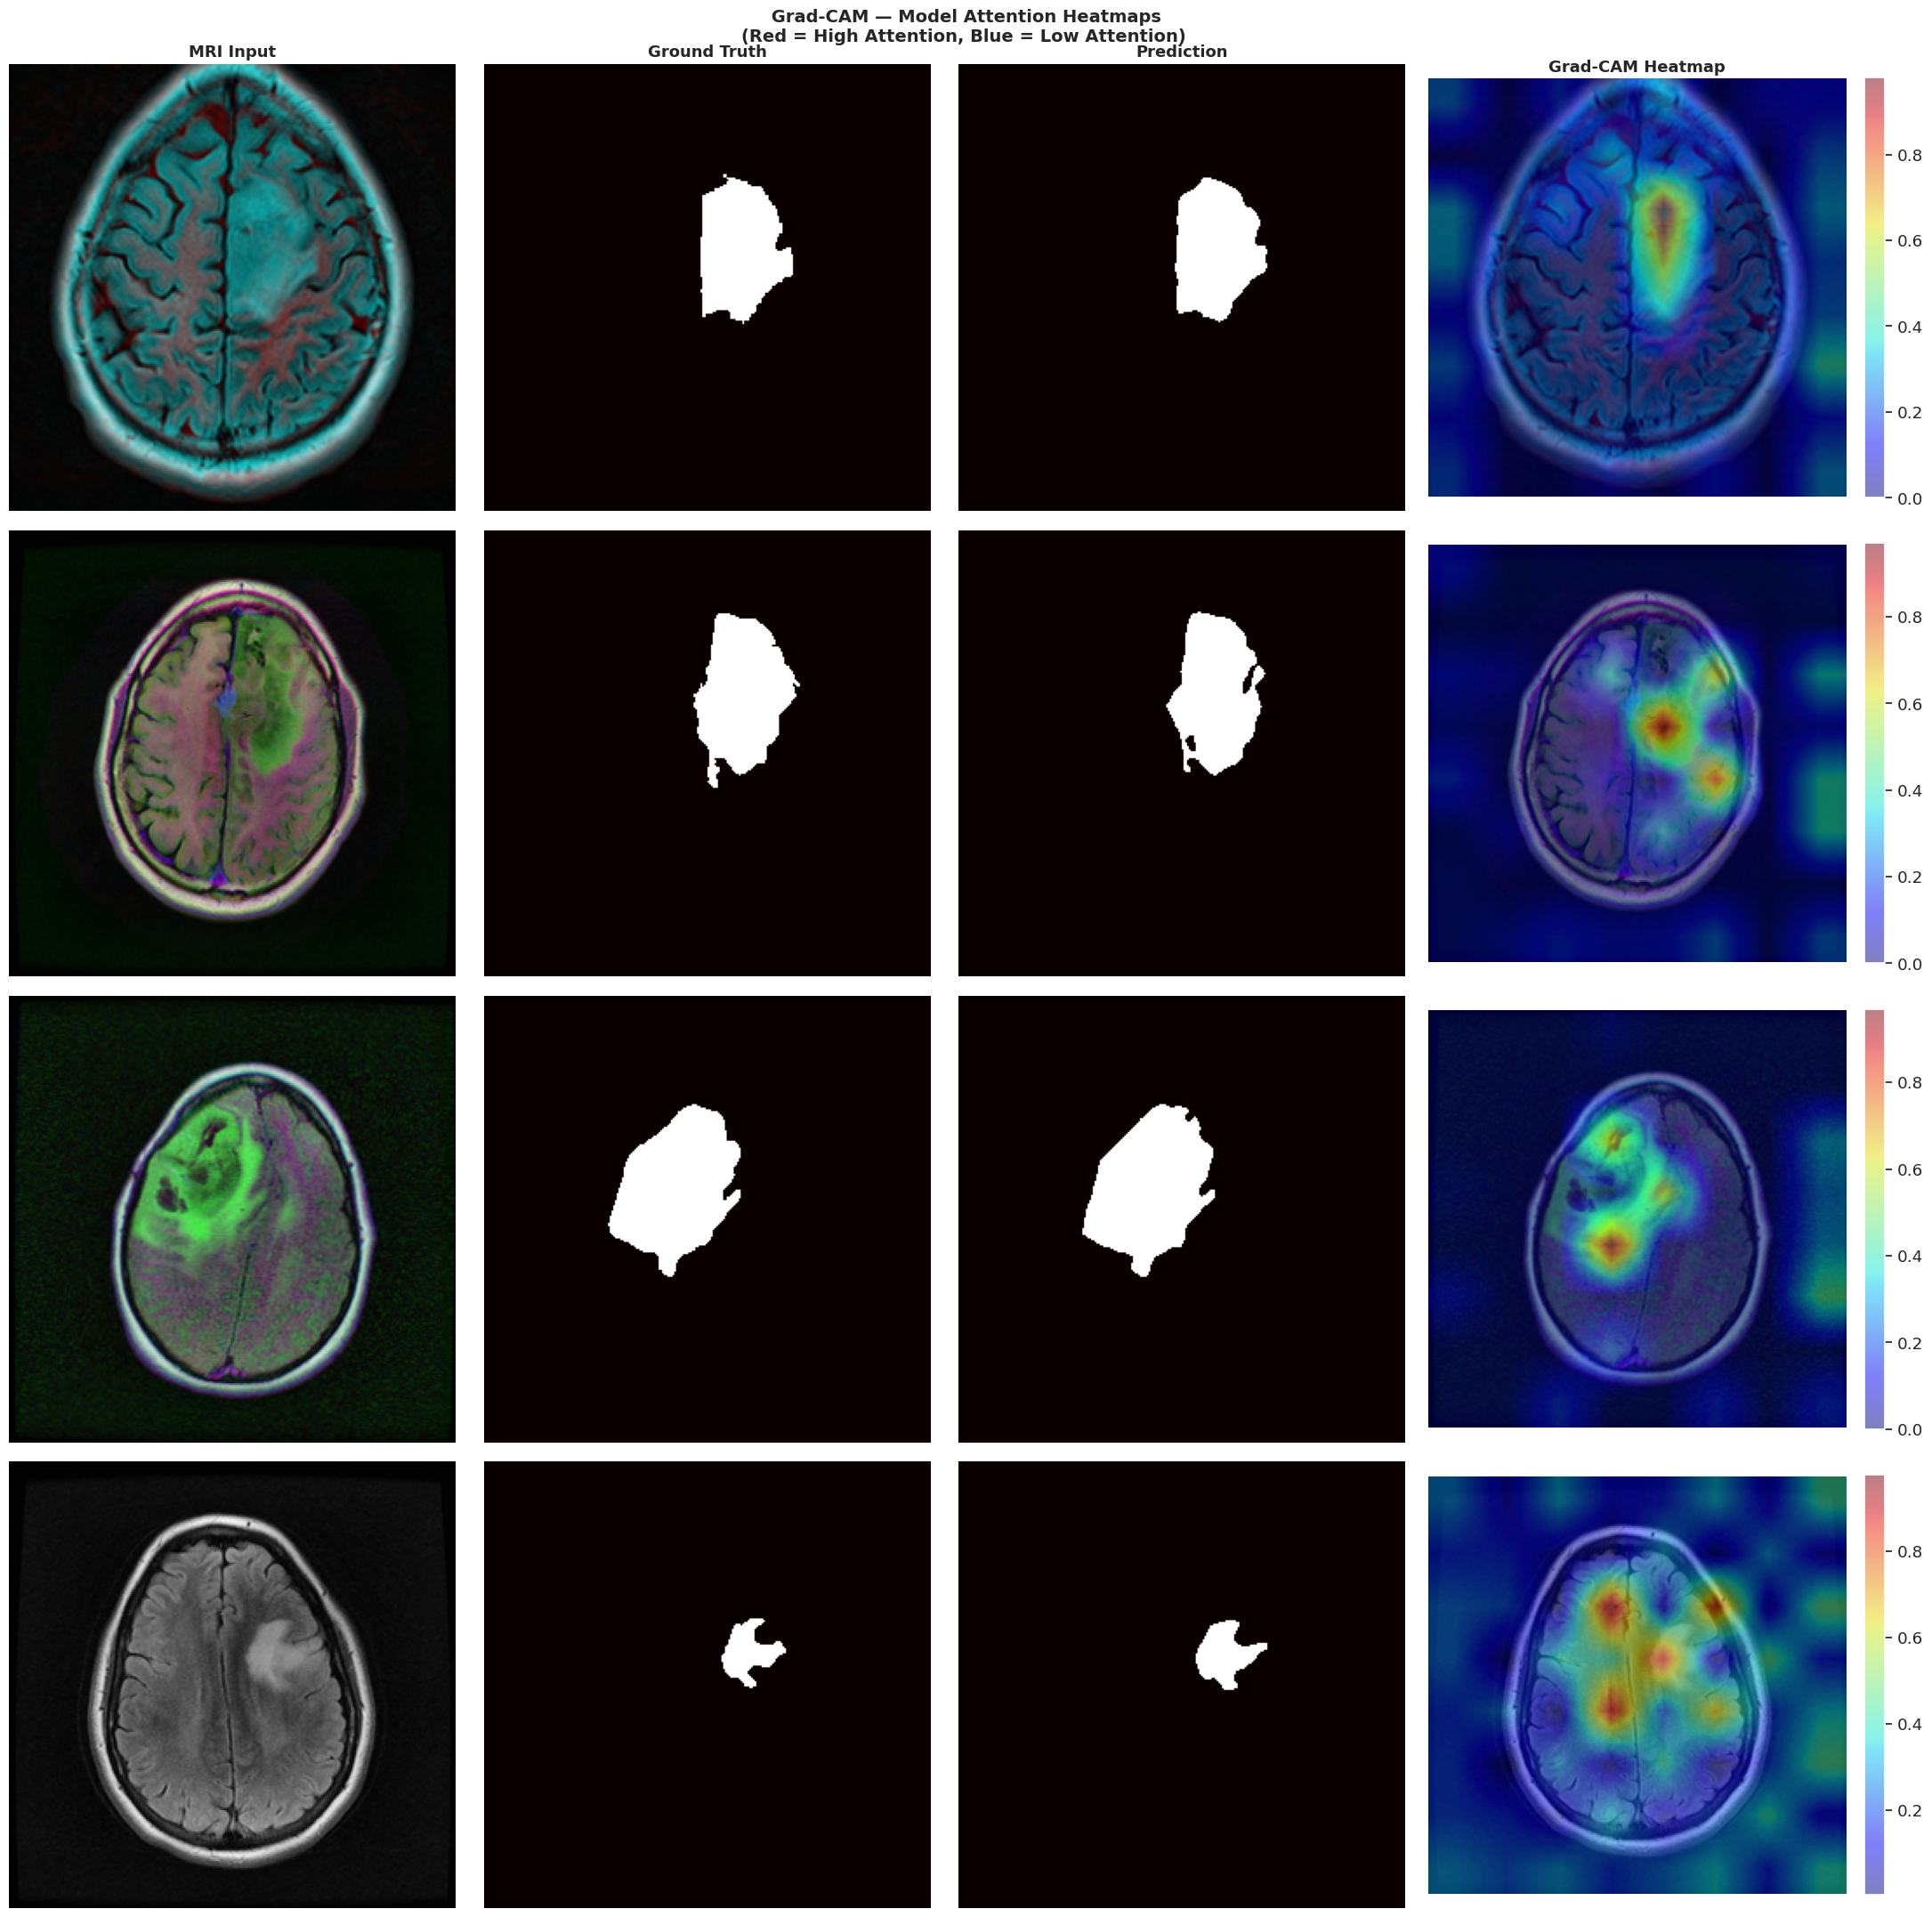

 Saved: gradcam_results.png


In [23]:
n_gradcam = 4
fig, axs = plt.subplots(n_gradcam, 4, figsize=(22, n_gradcam * 5.5))

col_titles = ['MRI Input', 'Ground Truth', 'Prediction', 'Grad-CAM Heatmap']
for ax, title in zip(axs[0], col_titles):
    ax.set_title(title, fontweight='bold', fontsize=13)

plotted = 0
for imgs, masks in test_loader:
    if plotted >= n_gradcam:
        break
    mask = masks[0]
    if not mask.byte().any():
        continue

    # Grad-CAM
    cam = grad_cam.generate(imgs)  # (H, W)

    with torch.no_grad():
        pred = model(imgs.to(device)).cpu()[0][0]
    pred_binary = (pred > 0.5).float()

    # De-normalize
    mean_t = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std_t  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    img_display = (imgs[0] * std_t + mean_t).clamp(0, 1).permute(1, 2, 0).numpy()

    # Resize CAM to input size
    cam_resized = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))

    axs[plotted, 0].imshow(img_display)
    axs[plotted, 0].axis('off')

    axs[plotted, 1].imshow(mask.numpy(), cmap='hot')
    axs[plotted, 1].axis('off')

    axs[plotted, 2].imshow(pred_binary.numpy(), cmap='hot')
    axs[plotted, 2].axis('off')

    # Grad-CAM overlay
    axs[plotted, 3].imshow(img_display)
    im = axs[plotted, 3].imshow(cam_resized, cmap='jet', alpha=0.45)
    axs[plotted, 3].axis('off')
    plt.colorbar(im, ax=axs[plotted, 3], fraction=0.046, pad=0.04)

    slice_iou  = iou_score(pred.unsqueeze(0), mask.unsqueeze(0)).item()
    slice_dice = dice_score(pred.unsqueeze(0), mask.unsqueeze(0)).item()
    axs[plotted, 0].set_ylabel(f'IoU={slice_iou:.3f}  Dice={slice_dice:.3f}',
                               fontsize=9, rotation=0, labelpad=85, va='center')

    plotted += 1

plt.suptitle(' Grad-CAM — Model Attention Heatmaps\n'
             '(Red = High Attention, Blue = Low Attention)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('gradcam_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: gradcam_results.png')

In [24]:
# ── Final Summary ─────────────────────────────────────────────────────────────
print('\n' + '='*60)
print('         TRAINING COMPLETE — FINAL SUMMARY')
print('='*60)
print(f'  Architecture : U-Net + EfficientNetB7 + SCSE Attention')
print(f'  Preprocessing: CLAHE + ImageNet Normalization')
print(f'  Augmentation : Flip, Rotate, Elastic, GridDistort, Noise')
print(f'  Loss Function: Dice+BCE (0.5 each)')
print(f'  Optimizer    : AdamW (lr=3e-4, wd=1e-4)')
print(f'  Scheduler    : CosineAnnealingLR')
print(f'  Grad Clipping: max_norm=1.0')
print('─'*60)
print(f'  Test Loss    : {mean_loss:.4f}')
print(f'  Test IoU     : {mean_iou:.4f}  ({mean_iou*100:.2f}%)')
print(f'  Test Dice    : {mean_dice:.4f}  ({mean_dice*100:.2f}%)')
print('='*60)


         TRAINING COMPLETE — FINAL SUMMARY
  Architecture : U-Net + EfficientNetB7 + SCSE Attention
  Preprocessing: CLAHE + ImageNet Normalization
  Augmentation : Flip, Rotate, Elastic, GridDistort, Noise
  Loss Function: Dice+BCE (0.5 each)
  Optimizer    : AdamW (lr=3e-4, wd=1e-4)
  Scheduler    : CosineAnnealingLR
  Grad Clipping: max_norm=1.0
────────────────────────────────────────────────────────────
  Test Loss    : 0.0656
  Test IoU     : 0.9096  (90.96%)
  Test Dice    : 0.9352  (93.52%)


In [25]:
import torch

MODEL_SAVE_PATH = 'brain_tumor_best_model.pth'

torch.save(model.state_dict(), MODEL_SAVE_PATH)

print(f" Model weights saved to: {MODEL_SAVE_PATH}")

 Model weights saved to: brain_tumor_best_model.pth
